In [1]:
import pandas as pd

# Chargement du fichier
df = pd.read_csv("Base_Montee_reduite_10-22.csv")

# Conversion de la colonne 'year_month' en type datetime et mise en index
df['year_month'] = pd.to_datetime(df['year_month'])
df.set_index('year_month', inplace=True)

# Aperçu des premières lignes
df.head()


,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass
year_month,,,,,,,
2010-01-01,13.668426,0.134212,0.146741,391.430000,34.692608,-1821.86,-739.09
2010-02-01,13.412240,0.146130,0.167043,393.227500,34.678696,-1798.05,-717.92
2010-03-01,11.343056,0.143185,0.189243,394.502500,34.702680,-1787.96,-605.84
2010-04-01,8.935583,0.084990,0.218566,394.480000,34.704070,-1815.11,-702.17
2010-05-01,7.603814,0.060147,0.234102,391.056667,34.729305,-1787.14,-742.25


In [2]:
from statsmodels.tsa.stattools import adfuller

# Application du test ADF à chaque colonne
adf_results = {}
for col in df.columns:
    result = adfuller(df[col].dropna())
    adf_results[col] = {
        'ADF Statistic': result[0],
        'p-value': result[1],
        'Stationary (5%)': result[1] < 0.05
    }

# Résumé des résultats sous forme de tableau
adf_df = pd.DataFrame(adf_results).T


In [3]:
adf_df.sort_values(by='p-value', ascending=True, inplace=True)
adf_df

,ADF Statistic,p-value,Stationary (5%)
chlorophylle,-8.508305,0.0,True
salinité,-3.797877,0.002929,True
sea level corrected adjusted,-2.867876,0.049213,True
antarctica_mass,-1.297374,0.630373,False
greenland_mass,-1.183029,0.680853,False
sst_anomaly_filtered,-0.05286,0.953936,False
CO2,0.188782,0.971625,False


In [4]:
# Copie du DataFrame
df_diff = df.copy()

# Différence simple
df_diff['sea level corrected adjusted'] = df_diff['sea level corrected adjusted'].diff()
for col in ['sst_anomaly_filtered', 'greenland_mass', 'antarctica_mass']:
    df_diff[col] = df_diff[col].diff()

# Différence saisonnière d’ordre 12
for col in ['chlorophylle', 'salinité', 'CO2']:
    df_diff[col] = df_diff[col].diff(12)

# Suppression des lignes avec NaN
df_diff.dropna(inplace=True)
df_diff.head()


,sea level corrected adjusted,chlorophylle,sst_anomaly_filtered,CO2,salinité,greenland_mass,antarctica_mass
year_month,,,,,,,
2011-01-01,-1.657314,-0.001784,0.002433,4.437500,0.036705,12.58,-36.14
2011-02-01,-2.291946,-0.006570,-0.011217,1.727500,0.040851,12.58,-36.14
2011-03-01,-1.757134,-0.022812,-0.014108,4.200000,0.024237,12.42,-23.91
2011-04-01,-0.407464,-0.009934,-0.017817,2.766667,0.018830,1.15,-28.96
2011-05-01,0.831614,0.002212,-0.006485,1.616667,-0.017675,-18.95,72.66


In [5]:
from statsmodels.tsa.api import VAR

# Construction du modèle VAR
model = VAR(df_diff)

# Sélection de l’ordre optimal jusqu’à 12 retards
order_selection = model.select_order(maxlags=12)

# Affichage des critères
order_selection.summary()


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


,AIC,BIC,FPE,HQIC
0,-1.277,-1.133,0.2789,-1.218
1,-4.812,-3.657,0.008141,-4.342
2,-6.253,-4.087*,0.001935,-5.373*
3,-6.409,-3.233,0.001675,-5.119
4,-6.434,-2.248,0.001669,-4.733
5,-6.583,-1.386,0.001492,-4.472
6,-6.763,-0.5557,0.001317*,-4.241
7,-6.534,0.6841,0.001794,-3.601
8,-6.748,1.481,0.001617,-3.404
9,-6.715,2.524,0.001932,-2.961


In [6]:
# Estimation du VAR d'ordre 2
var_model = model.fit(2)

# Affichage du résumé du modèle
var_model.summary()


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     17:08:18
--------------------------------------------------------------------
No. of Equations:         7.00000    BIC:                   -4.13553
Nobs:                     154.000    HQIC:                  -5.36508
Log likelihood:          -946.740    FPE:                 0.00202570
AIC:                     -6.20618    Det(Omega_mle):      0.00105685
--------------------------------------------------------------------
Results for equation sea level corrected adjusted
                                     coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------------
const                                   0.014381         0.039238            0.366           0.714
L1.sea level corrected adjusted         1.214070         0.05337

In [7]:
# On enlève la variable antarctica_mass
df_diff_reduced = df_diff.drop(columns=['antarctica_mass'])

# Nouveau modèle VAR
model_reduced = VAR(df_diff_reduced)

# Estimation du modèle VAR(2)
var_model_reduced = model_reduced.fit(2)

# Résumé
var_model_reduced.summary()


c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 20, May, 2025
Time:                     17:08:18
--------------------------------------------------------------------
No. of Equations:         6.00000    BIC:                   -13.7859
Nobs:                     154.000    HQIC:                  -14.6993
Log likelihood:          -53.1422    FPE:                2.21753e-07
AIC:                     -15.3241    Det(Omega_mle):     1.36363e-07
--------------------------------------------------------------------
Results for equation sea level corrected adjusted
                                     coefficient       std. error           t-stat            prob
--------------------------------------------------------------------------------------------------
const                                   0.006519         0.038652            0.169           0.866
L1.sea level corrected adjusted         1.223143         0.05256

In [8]:
import numpy as np
from statsmodels.stats.diagnostic import acorr_ljungbox
from scipy.stats import jarque_bera

# 1. Stabilité du modèle
stability = np.all(np.abs(var_model_reduced.roots) < 1)

# 2. Autocorrélation (Ljung-Box, lag 12)
ljungbox_results = {
    col: acorr_ljungbox(var_model_reduced.resid[col], lags=[2], return_df=True).iloc[0]
    for col in df_diff_reduced.columns
}

# 3. Normalité (Jarque-Bera)
jb_results = {
    col: jarque_bera(var_model_reduced.resid[col])
    for col in df_diff_reduced.columns
}


In [9]:
# 1. Prédiction en différences
forecast = var_model_reduced.forecast(df_diff_reduced.values[-2:], steps=12)
forecast_index = pd.date_range(start=df_diff_reduced.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
forecast_df = pd.DataFrame(forecast, index=forecast_index, columns=df_diff_reduced.columns)

# 2. Recomposition en niveau
last_values = df[df_diff_reduced.columns].iloc[-1]
forecast_level = forecast_df.cumsum().add(last_values)

# 3. Fusion avec l'historique
df_complete = pd.concat([df[df_diff_reduced.columns], forecast_level])


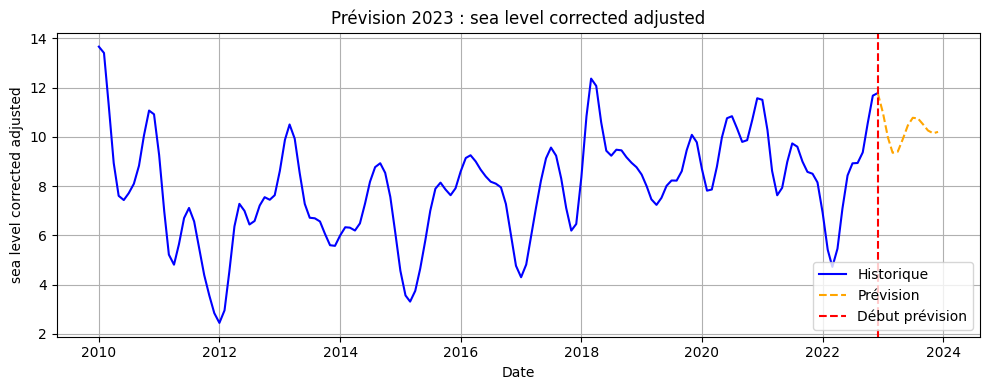

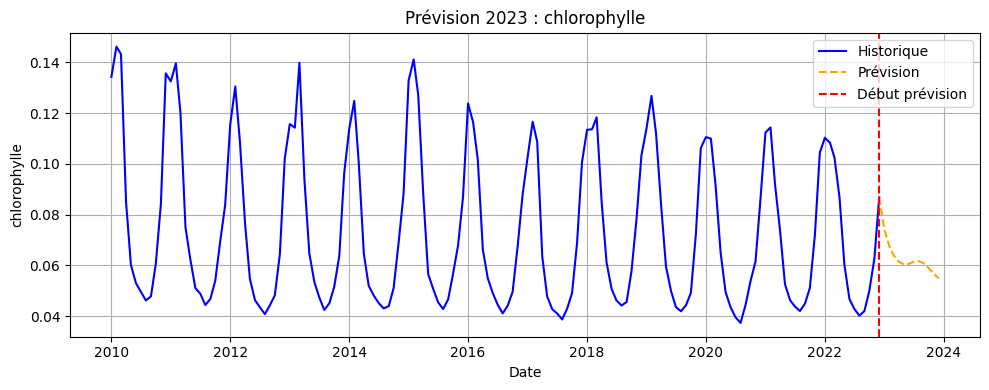

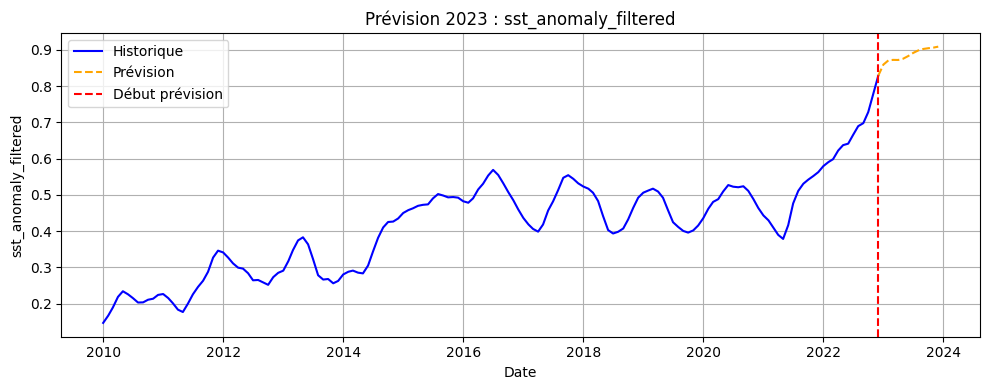

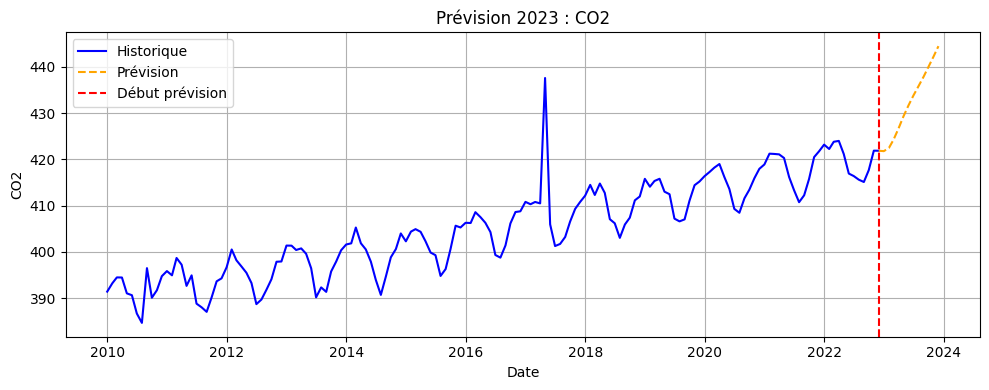

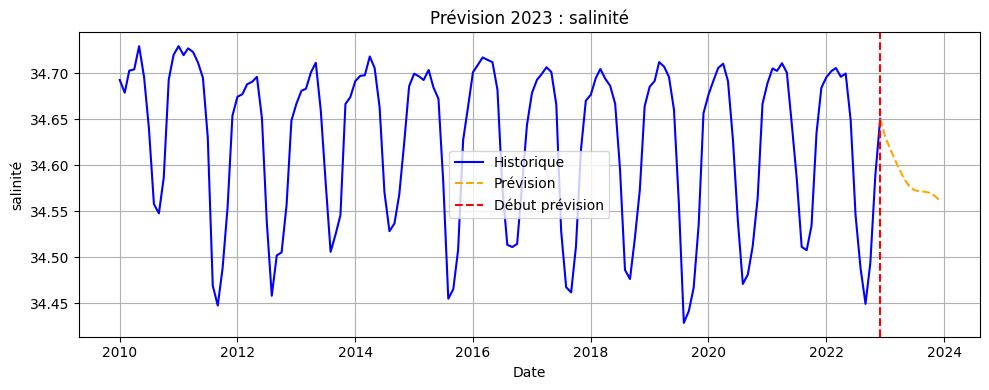

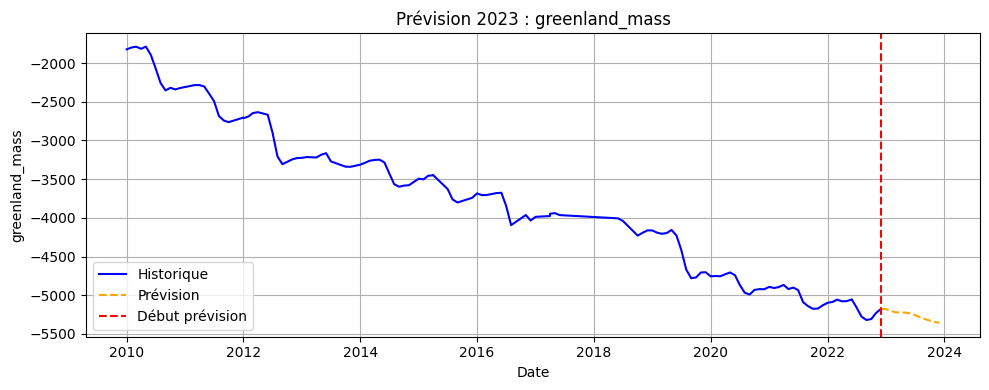

In [10]:
# Visualisation des prévisions en pointillés
import matplotlib.pyplot as plt

for col in df_diff_reduced.columns:
    plt.figure(figsize=(10, 4))

    # Partie historique
    plt.plot(
        df_complete.loc[:df.index[-1]].index,
        df_complete.loc[:df.index[-1], col],
        label="Historique",
        color="blue"
    )

    # Partie prévision
    plt.plot(
        df_complete.loc[df.index[-1]:].index,
        df_complete.loc[df.index[-1]:, col],
        label="Prévision",
        color="orange",
        linestyle="--"
    )

    # Ligne de coupure
    plt.axvline(x=df.index[-1], color="red", linestyle="--", label="Début prévision")

    # Mise en forme
    plt.title(f"Prévision 2023 : {col}")
    plt.xlabel("Date")
    plt.ylabel(col)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
